<a href="https://colab.research.google.com/github/Sahilkhan75786/Codveda_Technologies_/blob/main/Codveda_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving churn-bigml-20.csv to churn-bigml-20 (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv('churn-bigml-20.csv')
df

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662,WI,114,415,No,Yes,26,137.1,88,23.31,155.7,125,13.23,247.6,94,11.14,11.5,7,3.11,2,False
663,AL,106,408,No,Yes,29,83.6,131,14.21,203.9,131,17.33,229.5,73,10.33,8.1,3,2.19,1,False
664,VT,60,415,No,No,0,193.9,118,32.96,85.0,110,7.23,210.1,134,9.45,13.2,8,3.56,3,False
665,WV,159,415,No,No,0,169.8,114,28.87,197.7,105,16.80,193.7,82,8.72,11.6,4,3.13,1,False


In [ ]:
# Data Exploration
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types and missing values:")
print(df.info())
print("\nSummary statistics:")
print(df.describe())
print("\nChurn distribution:")
print(df['Churn'].value_counts(normalize=True))

Dataset shape: (667, 20)

First 5 rows:
  State  Account length  Area code International plan Voice mail plan  \
0    LA             117        408                 No              No   
1    IN              65        415                 No              No   
2    NY             161        415                 No              No   
3    SC             111        415                 No              No   
4    HI              49        510                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   
3                      0              110.4              103   
4                      0              119.3              117   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             31.37              351.6               80    

In [ ]:
# Visualizations
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Text(0.5, 1.0, 'Churn Distribution')

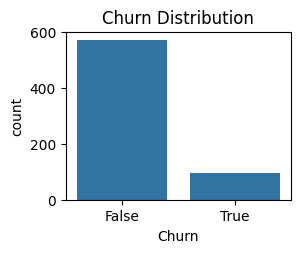

In [ ]:
# Churn distribution
plt.subplot(2, 2, 1)
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')

Text(0.5, 1.0, 'Churn by International Plan')

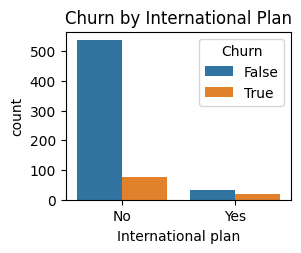

In [ ]:
# International plan vs churn
plt.subplot(2, 2, 2)
sns.countplot(x='International plan', hue='Churn', data=df)
plt.title('Churn by International Plan')

Text(0.5, 1.0, 'Customer Service Calls by Churn Status')

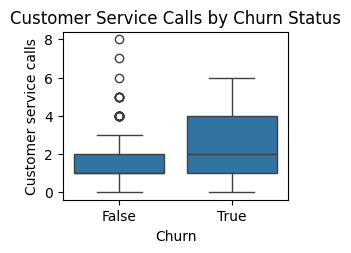

In [ ]:
# Customer service calls vs churn
plt.subplot(2, 2, 3)
sns.boxplot(x='Churn', y='Customer service calls', data=df)
plt.title('Customer Service Calls by Churn Status')

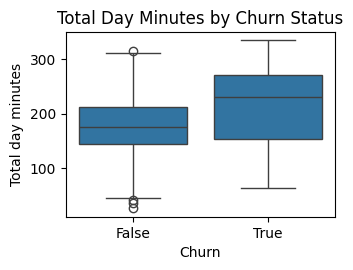

In [ ]:
# Total day minutes vs churn
plt.subplot(2, 2, 4)
sns.boxplot(x='Churn', y='Total day minutes', data=df)
plt.title('Total Day Minutes by Churn Status')
plt.tight_layout()
plt.show()

In [ ]:
#Feature Engineering
# Create new features that might be predictive
df['Total minutes'] = df['Total day minutes'] + df['Total eve minutes'] + df['Total night minutes']
df['Total calls'] = df['Total day calls'] + df['Total eve calls'] + df['Total night calls']
df['Total charge'] = df['Total day charge'] + df['Total eve charge'] + df['Total night charge']
df['Avg minutes per call'] = df['Total minutes'] / df['Total calls']
df['Charge per minute'] = df['Total charge'] / df['Total minutes']

In [ ]:
# Data Preprocessing
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Define categorical and numerical features
categorical_features = ['State', 'International plan', 'Voice mail plan']
numerical_features = [col for col in X.columns if col not in categorical_features + ['Area code']]

In [ ]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [ ]:
# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)

In [ ]:
# Model Building
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier()
}

In [ ]:
# Evaluate models
results = {}
for name, model in models.items():
    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model) # SMOTE will be applied outside the pipeline
    ])

    # Fit the pipeline on the training data
    X_train_processed = preprocessor.fit_transform(X_train)

    # Apply SMOTE to the preprocessed training data
    X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

    # Fit the classifier on the SMOTE-augmented training data
    pipeline.named_steps['classifier'].fit(X_train_smote, y_train_smote)


    # Make predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Store results
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    }

In [ ]:
# Convert results to DataFrame
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
print(results_df)


Model Performance Comparison:
                     Accuracy  Precision    Recall  F1 Score   ROC AUC
Logistic Regression  0.828358   0.428571  0.631579  0.510638  0.826087
Random Forest        0.932836   0.857143  0.631579  0.727273  0.920824
Gradient Boosting    0.970149   1.000000  0.789474  0.882353  0.908467
SVM                  0.940299   0.823529  0.736842  0.777778  0.914416
KNN                  0.798507   0.394737  0.789474  0.526316  0.854691


In [ ]:
# Feature Importance Analysis
# Get feature names after one-hot encoding
preprocessor.fit(X_train)
cat_features = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = numerical_features + list(cat_features)

In [ ]:
# Get feature importances from the Random Forest model
importances = rf_pipeline.named_steps['classifier'].feature_importances_

In [ ]:
# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

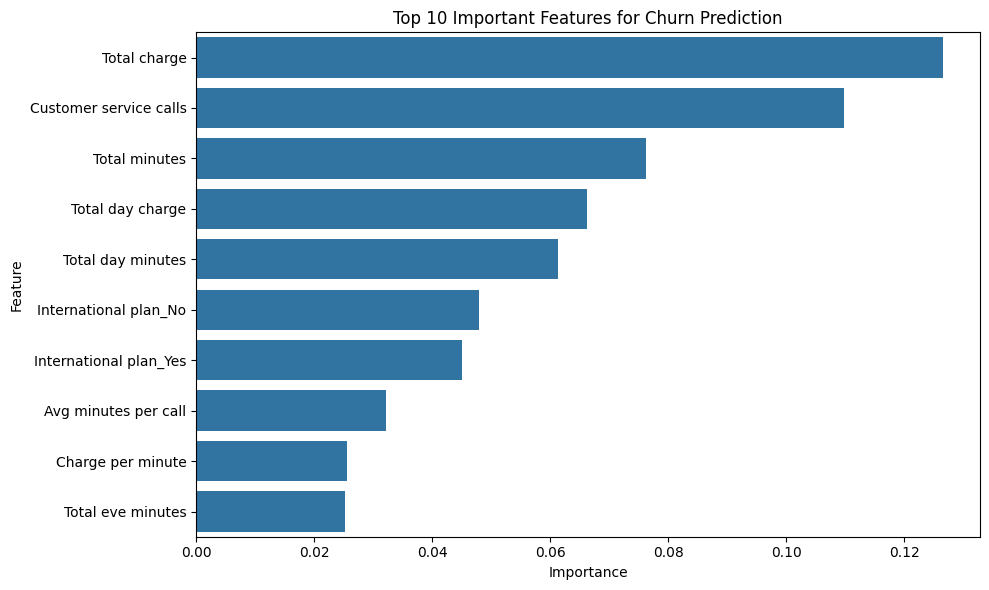

In [ ]:
# Plot top 10 most important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('Top 10 Important Features for Churn Prediction')
plt.tight_layout()
plt.show()

In [ ]:
# Hyperparameter Tuning for Random Forest
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [ ]:
# Fit the grid search to the data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Account '
                                                                          'length',
                                                                          'Number '
                                                                          'vmail '
                                                                          'messages',
                                                                          'Total '
                                                                          'day '
                                                                          'minutes',
                                                                          'Total '
                                                                          'day '
                                                                          'calls',
                                                                          'Total '
                                                                          'day '
                                                                          'charge',
                                                                          'Total '
                                                                          'eve '
                                                                          'minutes',
                                                                          'Total '
                                                                          'eve '
                                                                          'calls',
                                                                          'Total '
                                                                          'eve '
                                                                          'charge',
                                                                          'Total '
                                                                          'night '
                                                                          'minutes',
                                                                          'Total '
                                                                          'night '
                                                                          'calls',
                                                                          'Total '
                                                                          'night '
                                                                          'ch...
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['State',
                                                                          'International '
                                                                          'plan',
                                                                          'Voice '
                                                                          'mail '
                                                                          'plan'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='roc_auc', verbose=1)

In [ ]:
# Print best parameters and score
print("\nBest parameters:", grid_search.best_params_)
print("Best ROC AUC score:", grid_search.best_score_)


Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best ROC AUC score: 0.9109332696289218


In [ ]:
# Evaluate the tuned model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

In [ ]:
# Classification report
print("\nClassification Report for Tuned Model:")
print(classification_report(y_test, y_pred_tuned))


Classification Report for Tuned Model:
              precision    recall  f1-score   support

       False       0.95      1.00      0.97       115
        True       1.00      0.68      0.81        19

    accuracy                           0.96       134
   macro avg       0.98      0.84      0.89       134
weighted avg       0.96      0.96      0.95       134



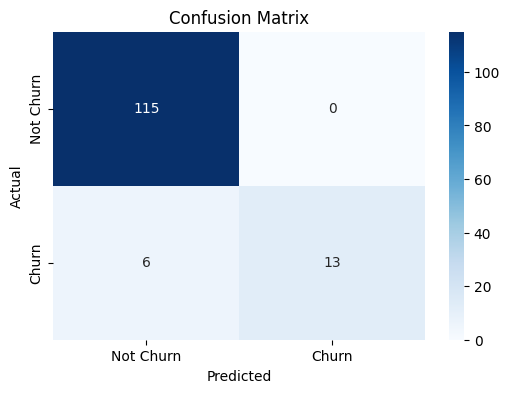

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# Market Segmentation using Clustering
# Select features for clustering
cluster_features = ['Total minutes', 'Total charge', 'Customer service calls', 'Total intl minutes']
X_cluster = df[cluster_features]

# Standardize the features
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

In [ ]:
# Determine optimal number of clusters using elbow method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

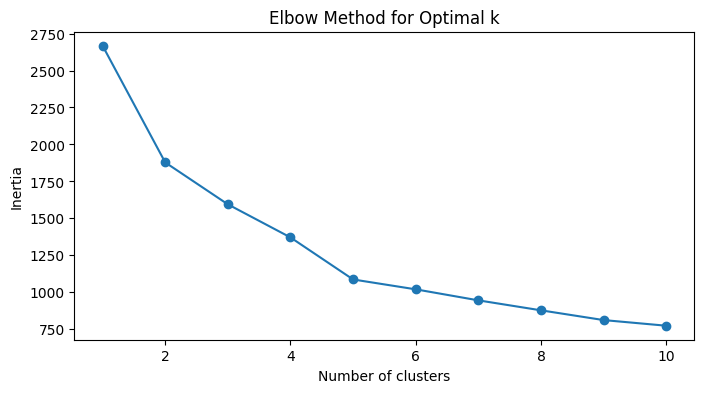

In [ ]:
# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
# Based on the elbow plot, choose optimal k (e.g., 3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_cluster_scaled)

In [ ]:
# Add clusters to original dataframe
df['Cluster'] = clusters

In [ ]:
# Analyze cluster characteristics
# Select only numeric columns for aggregation
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
cluster_analysis = df.groupby('Cluster')[numeric_cols + ['Churn']].mean()
print("\nCluster Analysis:")
print(cluster_analysis[cluster_features + ['Churn']])


Cluster Analysis:
         Total minutes  Total charge  Customer service calls  \
Cluster                                                        
0           599.535931     58.753247                0.965368   
1           677.833520     68.422123                1.815642   
2           504.651751     47.554125                1.926070   

         Total intl minutes     Churn  
Cluster                                
0                 12.071429  0.056277  
1                  8.575419  0.279330  
2                  9.749027  0.124514  


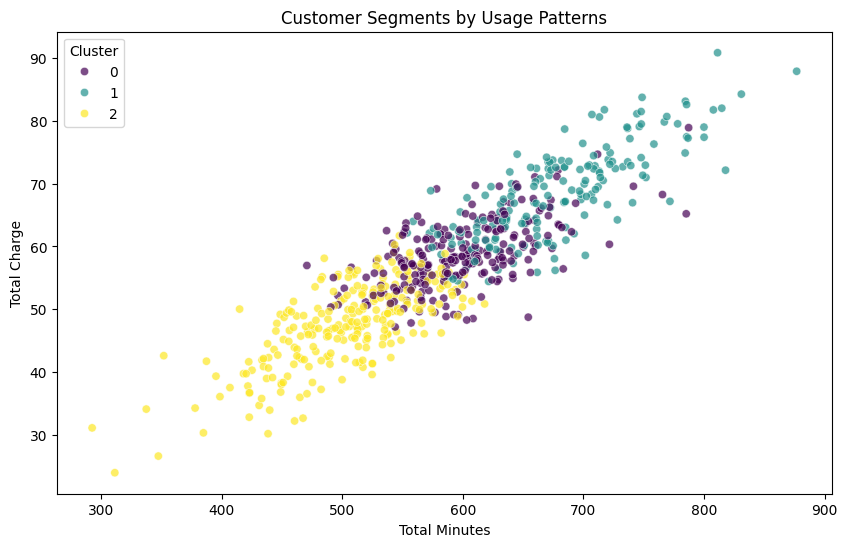

In [ ]:
# Visualize clusters in 2D space
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Total minutes',
    y='Total charge',
    hue='Cluster',
    data=df,
    palette='viridis',
    alpha=0.7
)
plt.title('Customer Segments by Usage Patterns')
plt.xlabel('Total Minutes')
plt.ylabel('Total Charge')
plt.show()

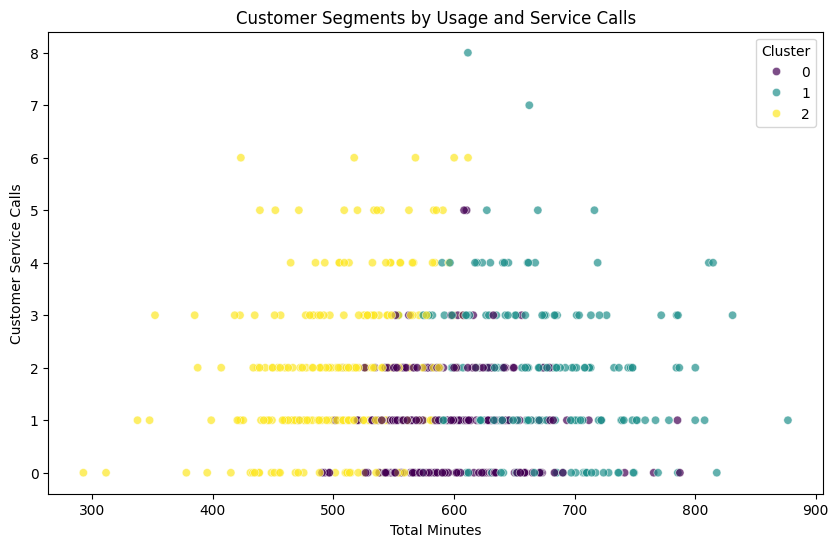

In [ ]:
# Visualization with customer service calls
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Total minutes',
    y='Customer service calls',
    hue='Cluster',
    data=df,
    palette='viridis',
    alpha=0.7
)
plt.title('Customer Segments by Usage and Service Calls')
plt.xlabel('Total Minutes')
plt.ylabel('Customer Service Calls')
plt.show()